# Parkinson's Disease Dataset - Exploratory Data Analysis (EDA)

## Project Overview

This notebook performs a comprehensive exploratory data analysis on the Parkinson's Disease Dataset from the University of Oxford. The dataset contains biomedical voice measurements from 31 people, 23 with Parkinson's disease (PD) and 8 healthy individuals.

### Dataset Information:
- **Total instances**: 197 voice recordings
- **Features**: 23 voice measurement attributes  
- **Target variable**: `status` (0 = healthy, 1 = Parkinson's disease)
- **Data source**: Max Little, University of Oxford

### Objectives:
1. Understand the dataset structure and quality
2. Analyze the distribution of features
3. Explore relationships between voice measurements and Parkinson's disease
4. Identify potential patterns for disease classification
5. Assess data quality and prepare insights for modeling


In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd                    # For data manipulation and analysis
import numpy as np                     # For numerical computations
import matplotlib.pyplot as plt        # For creating static visualizations
import seaborn as sns                  # For statistical data visualization
import warnings                        # For handling warning messages
from scipy import stats               # For statistical tests and functions

# Configure visualization settings
plt.style.use('default')              # Set matplotlib style to default
sns.set_palette("husl")               # Set seaborn color palette for better aesthetics
warnings.filterwarnings('ignore')     # Suppress warning messages for cleaner output

# Set display options for pandas
pd.set_option('display.max_columns', None)    # Display all columns when showing dataframes
pd.set_option('display.width', None)          # Remove width restrictions
pd.set_option('display.max_colwidth', None)   # Display full content of columns

print("Libraries imported successfully!")
print("Ready to begin Parkinson's Disease Dataset EDA")


Libraries imported successfully!
Ready to begin Parkinson's Disease Dataset EDA


## 1. Data Loading and Initial Exploration

Let's start by loading the dataset and examining its basic structure.


In [2]:
# Load the Parkinson's disease dataset
# The file is located in the parent directory relative to the notebooks folder
data_path = '../parkinsons.data'      # Path to the dataset file
df = pd.read_csv(data_path)           # Read the CSV file into a pandas DataFrame

# Display basic information about the dataset
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")   # Show number of rows and columns
print(f"Number of records: {df.shape[0]}")      # Total number of voice recordings
print(f"Number of features: {df.shape[1]}")     # Total number of columns including target


Dataset loaded successfully!
Dataset shape: (195, 24)
Number of records: 195
Number of features: 24


In [3]:
# Examine the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())                      # Display the first 5 rows to understand data structure

print("\n" + "="*80 + "\n")

# Display column names and their data types
print("Dataset Information:")
print(df.info())                      # Shows column names, non-null counts, and data types

print("\n" + "="*80 + "\n")

# Show column names for better understanding
print("Column names in the dataset:")
for i, col in enumerate(df.columns):  # Iterate through all column names with index
    print(f"{i+1:2d}. {col}")         # Print column number and name in formatted way


First 5 rows of the dataset:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0           0.00007   0.00370   0.00554     0.01109       0.04374   
1           0.00008   0.00465   0.00696     0.01394       0.06134   
2           0.00009   0.00544   0.00781     0.01633       0.05233   
3           0.00009   0.00502   0.00698     0.01505       0.05492   
4           0.00011   0.00655   0.00908     0.01966       0.06425   

   MDVP:Shimmer(dB)  Shimmer:APQ3  Shimmer:APQ5  MDVP:APQ  Shimmer:DDA  \
0            

## 2. Data Quality Assessment

Let's check for missing values, duplicates, and basic data quality issues.


In [4]:
# Check for missing values in the dataset
print("Missing Values Analysis:")
missing_values = df.isnull().sum()          # Count missing values per column
missing_percentage = (missing_values / len(df)) * 100    # Calculate percentage of missing values

# Create a summary of missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,                    # Column names
    'Missing_Count': missing_values,         # Number of missing values
    'Missing_Percentage': missing_percentage  # Percentage of missing values
})

# Display only columns with missing values (if any)
columns_with_missing = missing_summary[missing_summary['Missing_Count'] > 0]
if len(columns_with_missing) > 0:
    print(columns_with_missing)
else:
    print("No missing values found in the dataset!")

print(f"\nTotal missing values in dataset: {missing_values.sum()}")  # Total count of all missing values


Missing Values Analysis:
No missing values found in the dataset!

Total missing values in dataset: 0


In [5]:
# Check for duplicate records
print("Duplicate Records Analysis:")
duplicate_count = df.duplicated().sum()     # Count total duplicate rows
print(f"Number of duplicate records: {duplicate_count}")

# Check duplicates excluding the 'name' column (since same person can have multiple recordings)
duplicate_count_excl_name = df.drop('name', axis=1).duplicated().sum()  # Remove 'name' column and check duplicates
print(f"Number of duplicate records (excluding name): {duplicate_count_excl_name}")

# Display unique values count for key columns
print(f"\nUnique Analysis:")
print(f"Unique patients (names): {df['name'].nunique()}")          # Number of unique patients
print(f"Unique status values: {df['status'].nunique()}")           # Should be 2 (healthy/PD)
print(f"Status value distribution: {df['status'].value_counts().to_dict()}")  # Count of each status


Duplicate Records Analysis:
Number of duplicate records: 0
Number of duplicate records (excluding name): 0

Unique Analysis:
Unique patients (names): 195
Unique status values: 2
Status value distribution: {1: 147, 0: 48}


## 3. Target Variable Analysis

Let's analyze the distribution of our target variable (status) and understand the class balance.


Target Variable (Status) Analysis:
                    Status  Count  Percentage
0              Healthy (0)     48   24.615385
1  Parkinson's Disease (1)    147   75.384615

Class Balance Ratio (PD:Healthy) = 147:48


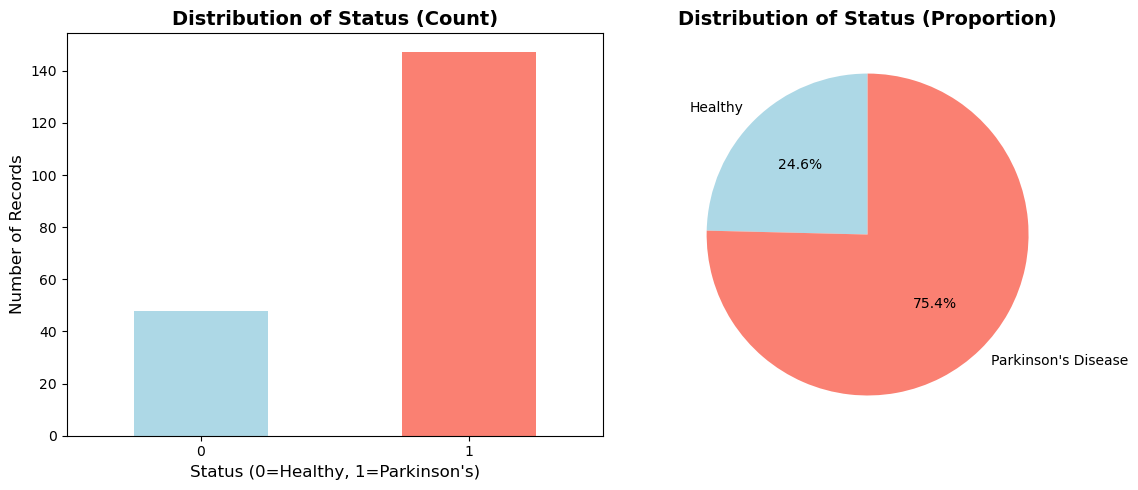

In [6]:
# Analyze the target variable distribution
print("Target Variable (Status) Analysis:")
print("="*50)

# Get value counts and percentages for status
status_counts = df['status'].value_counts().sort_index()   # Count occurrences of each status
status_percentages = df['status'].value_counts(normalize=True).sort_index() * 100  # Get percentages

# Create a summary table
status_summary = pd.DataFrame({
    'Status': ['Healthy (0)', 'Parkinson\'s Disease (1)'],  # Human-readable labels
    'Count': status_counts.values,                          # Raw counts
    'Percentage': status_percentages.values                 # Percentage values
})

print(status_summary)
print(f"\nClass Balance Ratio (PD:Healthy) = {status_counts[1]}:{status_counts[0]}")  # Show ratio

# Visualize the distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))     # Create subplot with 2 plots side by side

# Bar plot showing counts
status_counts.plot(kind='bar', ax=ax1, color=['lightblue', 'salmon'])  # Bar chart with different colors
ax1.set_title('Distribution of Status (Count)', fontsize=14, fontweight='bold')  # Set title
ax1.set_xlabel('Status (0=Healthy, 1=Parkinson\'s)', fontsize=12)      # X-axis label
ax1.set_ylabel('Number of Records', fontsize=12)                       # Y-axis label
ax1.tick_params(axis='x', rotation=0)                                   # Keep x-axis labels horizontal

# Pie chart showing proportions
ax2.pie(status_counts.values, labels=['Healthy', 'Parkinson\'s Disease'], 
        autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])  # Pie chart with percentages
ax2.set_title('Distribution of Status (Proportion)', fontsize=14, fontweight='bold')  # Set title

plt.tight_layout()                    # Adjust spacing between subplots
plt.show()                           # Display the plots


## 4. Statistical Summary

Let's examine the statistical properties of all numerical features.


In [7]:
# Separate numerical features from categorical ones
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()  # Get all numerical columns
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()  # Get all non-numerical columns

print("Feature Types Analysis:")
print(f"Numerical features: {len(numerical_features)}")   # Count of numerical features
print(f"Categorical features: {len(categorical_features)}")  # Count of categorical features

print(f"\nCategorical features: {categorical_features}")   # List categorical features (likely just 'name')
print(f"Numerical features: {numerical_features[:10]}...")  # Show first 10 numerical features

# Generate comprehensive statistical summary
print("\nStatistical Summary of Numerical Features:")
statistical_summary = df[numerical_features].describe()    # Generate descriptive statistics
print(statistical_summary)                                 # Display the summary table


Feature Types Analysis:
Numerical features: 23
Categorical features: 1

Categorical features: ['name']
Numerical features: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)']...

Statistical Summary of Numerical Features:
       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count   195.000000    195.000000    195.000000      195.000000   
mean    154.228641    197.104918    116.324631        0.006220   
std      41.390065     91.491548     43.521413        0.004848   
min      88.333000    102.145000     65.476000        0.001680   
25%     117.572000    134.862500     84.291000        0.003460   
50%     148.790000    175.829000    104.315000        0.004940   
75%     182.769000    224.205500    140.018500        0.007365   
max     260.105000    592.030000    239.170000        0.033160   

       MDVP:Jitter(Abs)    MDVP:RAP    MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  

In [8]:
# Analyze features by categories based on their medical meaning
# Group features based on voice measurement types as described in the dataset documentation

# Define feature groups based on their medical/technical meaning
feature_groups = {
    'Fundamental_Frequency': ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)'],  # Basic frequency measures
    'Jitter_Measures': ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP'],  # Frequency variation
    'Shimmer_Measures': ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA'],  # Amplitude variation
    'Noise_Ratio': ['NHR', 'HNR'],  # Noise-to-harmonic ratios
    'Nonlinear_Dynamics': ['RPDE', 'D2', 'DFA'],  # Complexity measures
    'Frequency_Variation': ['spread1', 'spread2', 'PPE'],  # Fundamental frequency variation measures
    'Target': ['status']  # Target variable
}

# Display summary statistics for each group
for group_name, features in feature_groups.items():
    print(f"\n{group_name.upper()} MEASURES:")
    print("="*60)
    
    # Check which features exist in our dataset (some might be missing)
    existing_features = [f for f in features if f in df.columns]  # Filter to existing columns
    
    if existing_features:
        group_summary = df[existing_features].describe()           # Get statistics for this group
        print(f"Features in this group: {existing_features}")     # List the features
        print("\nStatistical Summary:")
        print(group_summary.round(4))                             # Display rounded statistics
    else:
        print("No features found in this group")                  # Handle case where no features exist



FUNDAMENTAL_FREQUENCY MEASURES:
Features in this group: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']

Statistical Summary:
       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)
count     195.0000      195.0000      195.0000
mean      154.2286      197.1049      116.3246
std        41.3901       91.4915       43.5214
min        88.3330      102.1450       65.4760
25%       117.5720      134.8625       84.2910
50%       148.7900      175.8290      104.3150
75%       182.7690      224.2055      140.0185
max       260.1050      592.0300      239.1700

JITTER_MEASURES MEASURES:
Features in this group: ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP']

Statistical Summary:
       MDVP:Jitter(%)  MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP
count        195.0000          195.0000  195.0000  195.0000    195.0000
mean           0.0062            0.0000    0.0033    0.0034      0.0099
std            0.0048            0.0000    0.0030    0.0028      0.0089
min         

## 5. Feature Distribution Analysis

Let's examine the distributions of key features and compare them between healthy and Parkinson's patients.


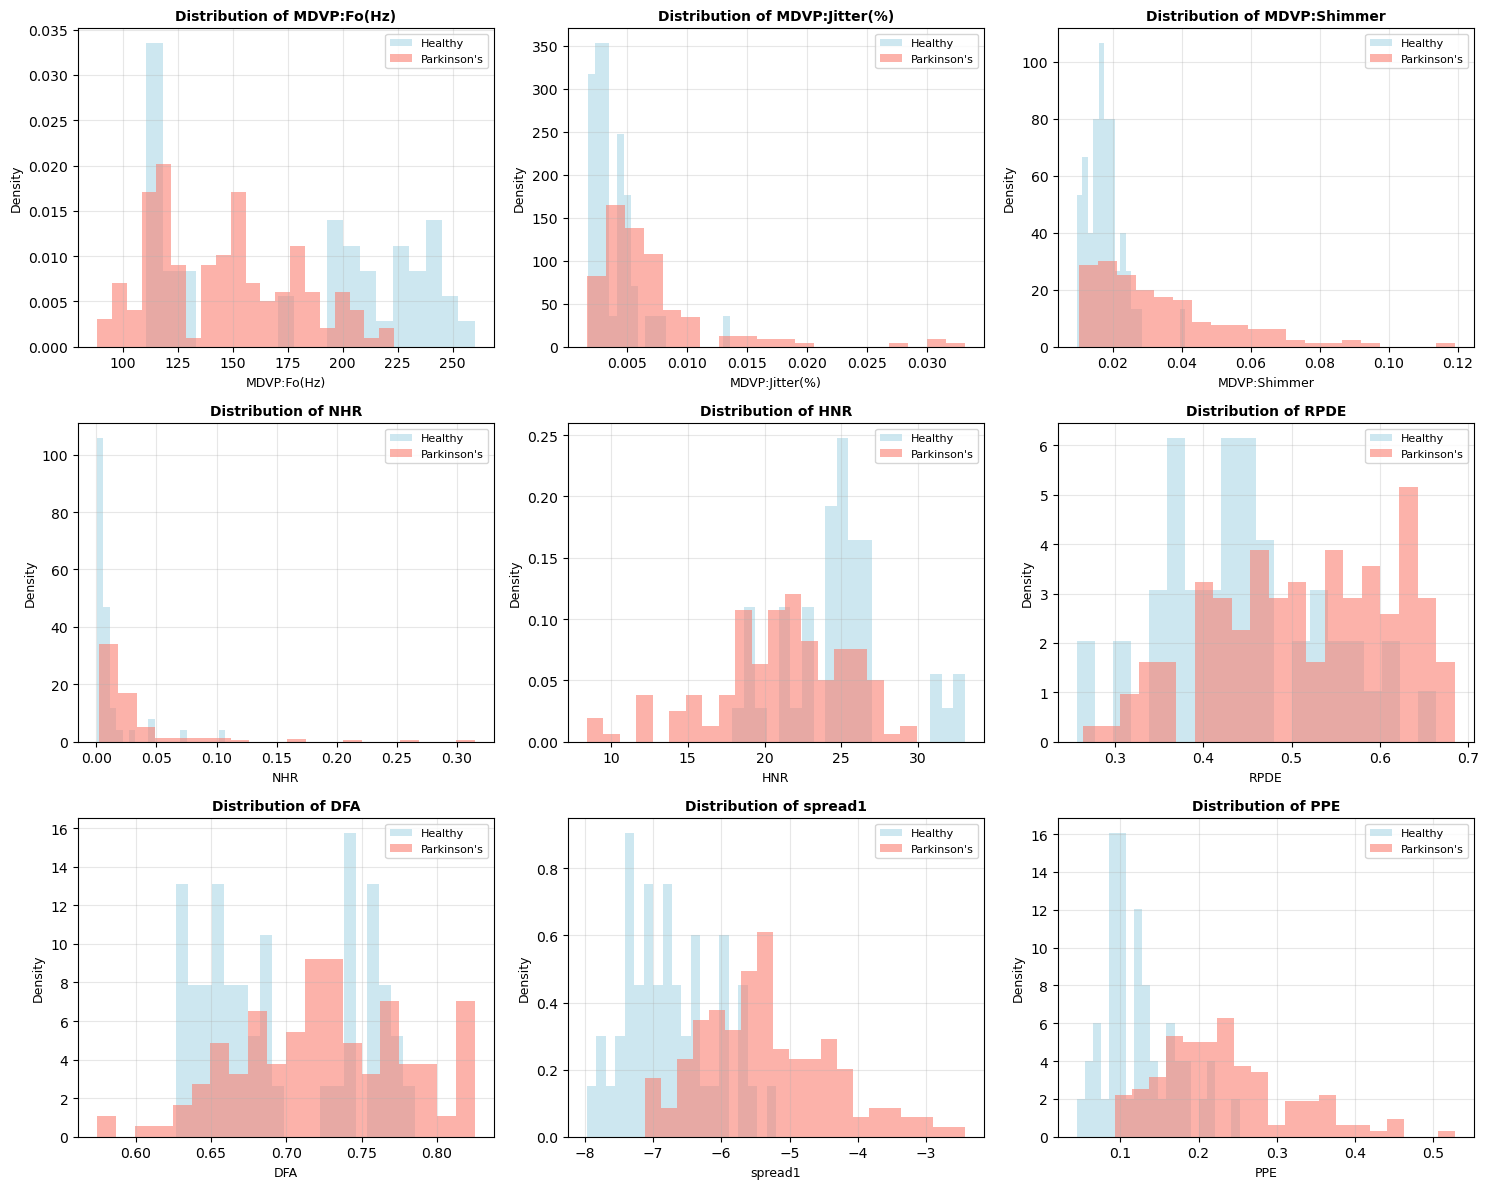

In [9]:
# Select key features for distribution analysis
# We'll focus on representative features from each measurement category
key_features = [
    'MDVP:Fo(Hz)',          # Fundamental frequency - basic voice measure
    'MDVP:Jitter(%)',       # Jitter - frequency variation
    'MDVP:Shimmer',         # Shimmer - amplitude variation  
    'NHR',                  # Noise-to-Harmonic Ratio
    'HNR',                  # Harmonic-to-Noise Ratio
    'RPDE',                 # Nonlinear complexity measure
    'DFA',                  # Fractal scaling exponent
    'spread1',              # Fundamental frequency variation
    'PPE'                   # Pitch period entropy
]

# Create histograms to show distributions for each key feature
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Create 3x3 subplot grid
axes = axes.ravel()                                # Flatten the axes array for easier indexing

# Plot distribution for each key feature
for i, feature in enumerate(key_features):
    ax = axes[i]                                   # Get current subplot
    
    # Plot histograms for both classes (healthy vs Parkinson's)
    healthy_data = df[df['status'] == 0][feature]         # Data for healthy patients  
    parkinsons_data = df[df['status'] == 1][feature]      # Data for Parkinson's patients
    
    # Create overlapping histograms with transparency
    ax.hist(healthy_data, bins=20, alpha=0.6, label='Healthy', color='lightblue', density=True)
    ax.hist(parkinsons_data, bins=20, alpha=0.6, label='Parkinson\'s', color='salmon', density=True)
    
    # Customize subplot
    ax.set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')  # Set title
    ax.set_xlabel(feature, fontsize=9)                     # X-axis label
    ax.set_ylabel('Density', fontsize=9)                   # Y-axis label
    ax.legend(fontsize=8)                                  # Add legend
    ax.grid(True, alpha=0.3)                              # Add light grid

plt.tight_layout()                                         # Adjust spacing between subplots
plt.show()                                                # Display the plot


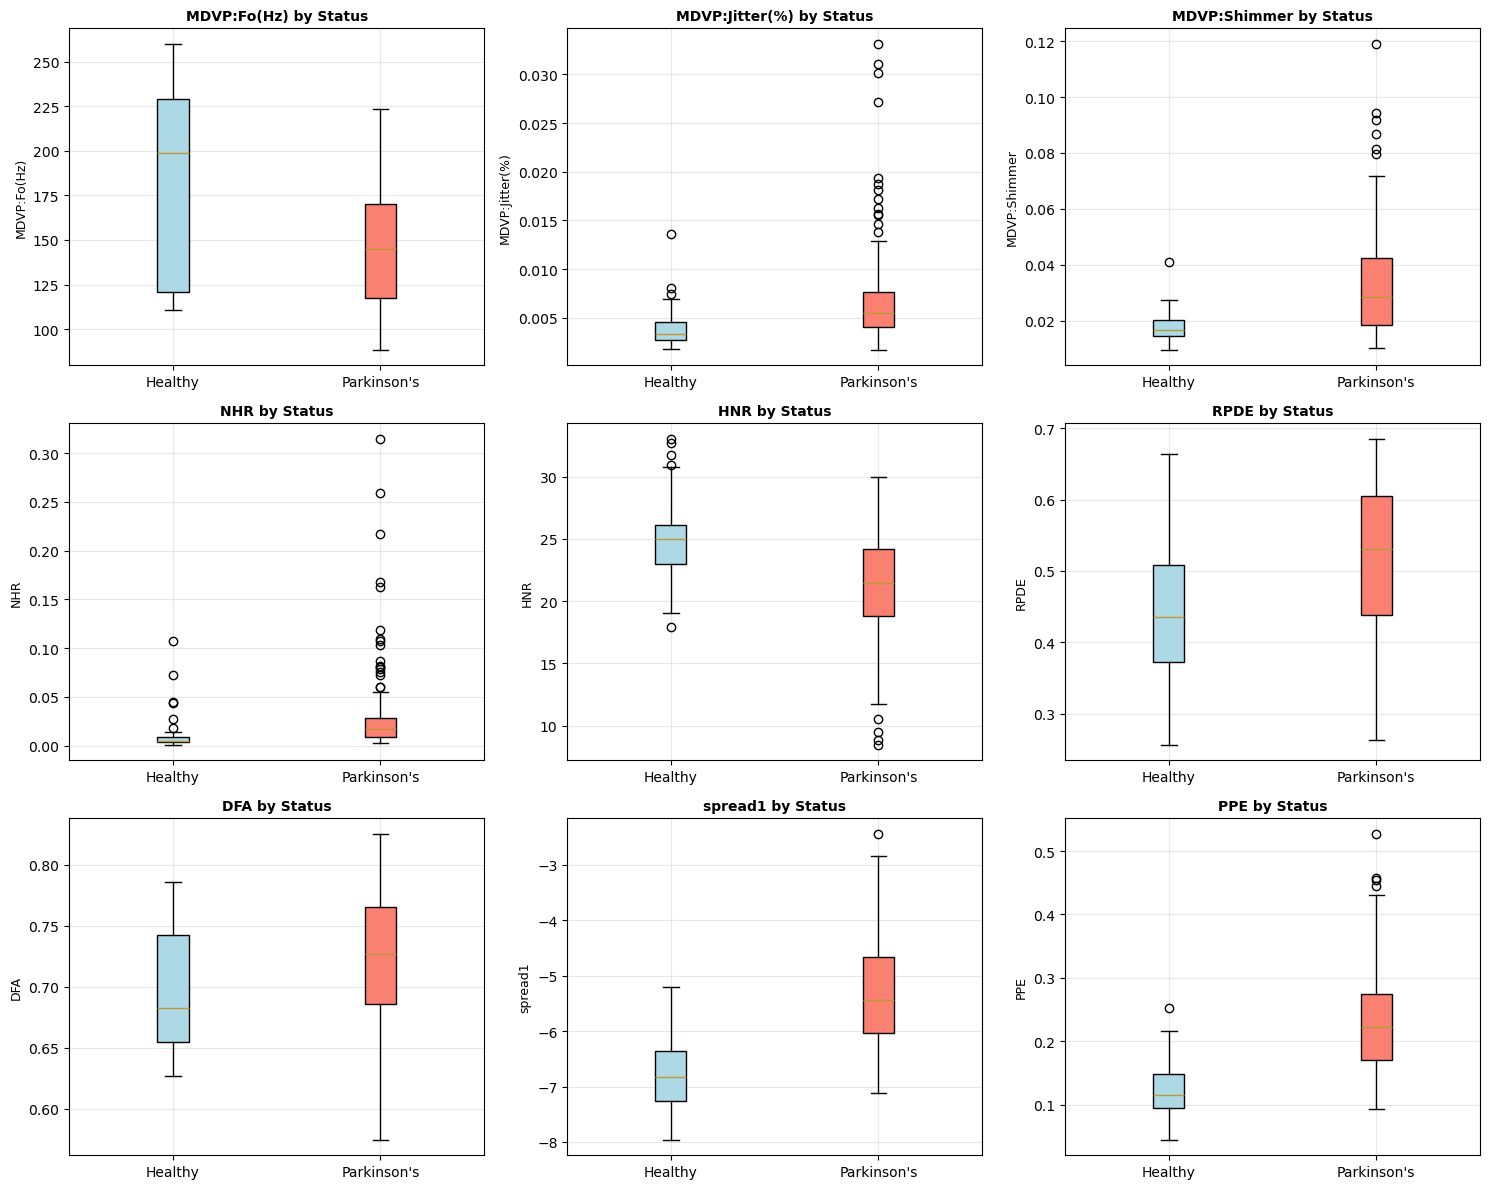

In [10]:
# Create box plots to better compare distributions between groups
# Box plots show median, quartiles, and outliers more clearly

fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Create 3x3 subplot grid
axes = axes.ravel()                                # Flatten axes for easier access

# Create box plots for each key feature
for i, feature in enumerate(key_features):
    ax = axes[i]                                   # Get current subplot
    
    # Create box plot comparing healthy vs Parkinson's patients
    box_data = [df[df['status'] == 0][feature],           # Healthy patients data
                df[df['status'] == 1][feature]]           # Parkinson's patients data
    
    # Create the box plot
    box_plot = ax.boxplot(box_data, labels=['Healthy', 'Parkinson\'s'], 
                         patch_artist=True)              # Enable color filling
    
    # Customize box colors
    box_plot['boxes'][0].set_facecolor('lightblue')      # Healthy group color
    box_plot['boxes'][1].set_facecolor('salmon')         # Parkinson's group color
    
    # Customize subplot appearance
    ax.set_title(f'{feature} by Status', fontsize=10, fontweight='bold')  # Set title
    ax.set_ylabel(feature, fontsize=9)                    # Y-axis label
    ax.grid(True, alpha=0.3)                             # Add light grid

plt.tight_layout()                                        # Adjust spacing
plt.show()                                               # Display the plot


## 6. Statistical Tests for Group Differences

Let's perform statistical tests to determine if there are significant differences between healthy and Parkinson's patients for each feature.


In [11]:
# Perform statistical tests to compare features between healthy and Parkinson's groups
# We'll use Mann-Whitney U test (non-parametric) as it doesn't assume normal distribution

print("Statistical Significance Tests (Mann-Whitney U Test)")
print("="*70)
print("Testing if there are significant differences between Healthy and Parkinson's groups")
print("H0: No difference between groups")
print("H1: Significant difference between groups")
print("Significance level: α = 0.05")
print()

# Initialize lists to store results
test_results = []

# Test each key feature for group differences
for feature in key_features:
    # Split data by status groups
    healthy_group = df[df['status'] == 0][feature]        # Healthy patients data
    parkinsons_group = df[df['status'] == 1][feature]     # Parkinson's patients data
    
    # Perform Mann-Whitney U test (non-parametric test for comparing two groups)
    statistic, p_value = stats.mannwhitneyu(healthy_group, parkinsons_group, 
                                           alternative='two-sided')  # Two-tailed test
    
    # Calculate effect size (Cohen's d) for practical significance
    # Effect size helps understand the magnitude of difference, not just statistical significance
    pooled_std = np.sqrt(((len(healthy_group) - 1) * healthy_group.var() + 
                         (len(parkinsons_group) - 1) * parkinsons_group.var()) / 
                        (len(healthy_group) + len(parkinsons_group) - 2))  # Pooled standard deviation
    
    cohens_d = (parkinsons_group.mean() - healthy_group.mean()) / pooled_std  # Cohen's d calculation
    
    # Determine significance level
    if p_value < 0.001:
        significance = "***"      # Highly significant
    elif p_value < 0.01:
        significance = "**"       # Very significant  
    elif p_value < 0.05:
        significance = "*"        # Significant
    else:
        significance = "ns"       # Not significant
    
    # Store results
    test_results.append({
        'Feature': feature,
        'Healthy_Mean': healthy_group.mean(),
        'Parkinsons_Mean': parkinsons_group.mean(),
        'P_Value': p_value,
        'Cohens_D': cohens_d,
        'Significance': significance
    })
    
    # Print detailed results for each feature
    print(f"{feature}:")
    print(f"  Healthy mean:     {healthy_group.mean():.4f}")
    print(f"  Parkinson's mean: {parkinsons_group.mean():.4f}")
    print(f"  P-value:          {p_value:.6f} {significance}")
    print(f"  Cohen's d:        {cohens_d:.4f}")
    print()

# Create summary DataFrame of all test results
results_df = pd.DataFrame(test_results)
print("\nSUMMARY TABLE:")
print(results_df.round(4))                               # Display rounded results table


Statistical Significance Tests (Mann-Whitney U Test)
Testing if there are significant differences between Healthy and Parkinson's groups
H0: No difference between groups
H1: Significant difference between groups
Significance level: α = 0.05

MDVP:Fo(Hz):
  Healthy mean:     181.9378
  Parkinson's mean: 145.1808
  P-value:          0.000031 ***
  Cohen's d:        -0.9591

MDVP:Jitter(%):
  Healthy mean:     0.0039
  Parkinson's mean: 0.0070
  P-value:          0.000000 ***
  Cohen's d:        0.6690

MDVP:Shimmer:
  Healthy mean:     0.0176
  Parkinson's mean: 0.0337
  P-value:          0.000000 ***
  Cohen's d:        0.9124

NHR:
  Healthy mean:     0.0115
  Parkinson's mean: 0.0292
  P-value:          0.000000 ***
  Cohen's d:        0.4456

HNR:
  Healthy mean:     24.6787
  Parkinson's mean: 20.9740
  P-value:          0.000001 ***
  Cohen's d:        -0.8955

RPDE:
  Healthy mean:     0.4426
  Parkinson's mean: 0.5168
  P-value:          0.000017 ***
  Cohen's d:        0.7492

D

## 7. Correlation Analysis

Let's examine the relationships between different voice features and identify potential multicollinearity issues.


In [12]:
# Identify highly correlated feature pairs for potential multicollinearity issues
print("High Correlation Pairs (|r| > 0.8):")
print("="*50)

# Find correlation pairs above threshold
high_corr_pairs = []
threshold = 0.8

# Calculate correlation matrix for numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
features_for_correlation = [col for col in numerical_features if col != "name"]
correlation_matrix = df[features_for_correlation].corr()

# Iterate through correlation matrix to find high correlations
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):  # Only check upper triangle
        corr_value = correlation_matrix.iloc[i, j]         # Get correlation value
        if abs(corr_value) > threshold:                    # Check if above threshold
            high_corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j], 
                'Correlation': corr_value
            })

# Display high correlation pairs
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)          # Create DataFrame from results
    high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False)  # Sort by absolute correlation
    print(high_corr_df)
    print(f"\nTotal high correlation pairs found: {len(high_corr_pairs)}")
else:
    print("No correlation pairs above threshold found")

print(f"\nCorrelation with target variable (status):")
target_correlations = correlation_matrix['status'].sort_values(key=abs, ascending=False)[1:]  # Exclude self-correlation
print(target_correlations.head(10))                      # Show top 10 correlations with target

High Correlation Pairs (|r| > 0.8):
           Feature_1         Feature_2  Correlation
31      Shimmer:APQ3       Shimmer:DDA     1.000000
11          MDVP:RAP        Jitter:DDP     1.000000
3     MDVP:Jitter(%)        Jitter:DDP     0.990276
1     MDVP:Jitter(%)          MDVP:RAP     0.990276
22      MDVP:Shimmer       Shimmer:DDA     0.987626
19      MDVP:Shimmer      Shimmer:APQ3     0.987625
18      MDVP:Shimmer  MDVP:Shimmer(dB)     0.987258
20      MDVP:Shimmer      Shimmer:APQ5     0.982835
2     MDVP:Jitter(%)          MDVP:PPQ     0.974256
25  MDVP:Shimmer(dB)      Shimmer:APQ5     0.973751
27  MDVP:Shimmer(dB)       Shimmer:DDA     0.963202
24  MDVP:Shimmer(dB)      Shimmer:APQ3     0.963198
39           spread1               PPE     0.962435
26  MDVP:Shimmer(dB)          MDVP:APQ     0.960977
34      Shimmer:APQ5       Shimmer:DDA     0.960072
29      Shimmer:APQ3      Shimmer:APQ5     0.960070
13          MDVP:PPQ        Jitter:DDP     0.957319
10          MDVP:RAP        

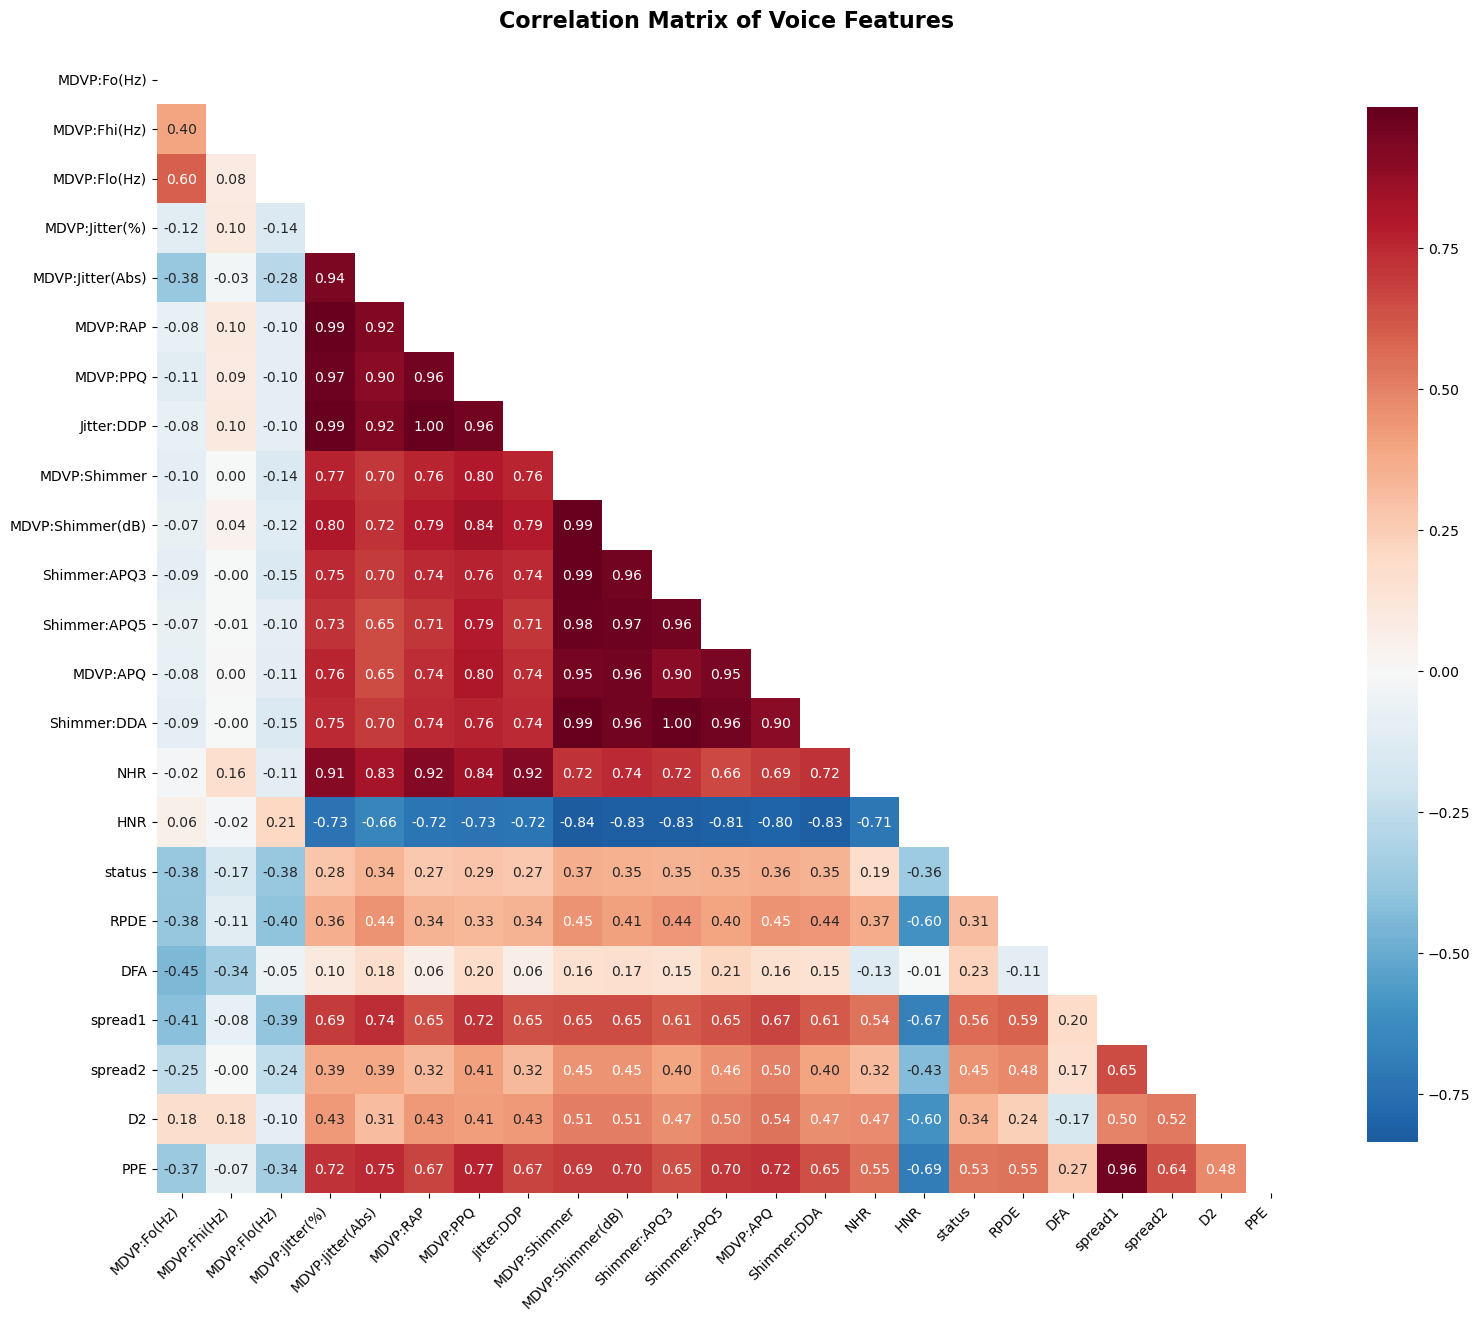

In [14]:
# Calculate correlation matrix for numerical features
# Remove 'name' column if it exists in numerical features (it's categorical)
features_for_correlation = [
    col for col in numerical_features if col != "name"
]  # Exclude name column

# Calculate Pearson correlation coefficients between all numerical features
correlation_matrix = df[features_for_correlation].corr()  # Compute correlation matrix

# Create a comprehensive correlation heatmap
plt.figure(figsize=(16, 14))  # Set large figure size for readability
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)  # Create mask to show only lower triangle

# Create heatmap with custom settings
sns.heatmap(
    correlation_matrix,
    mask=mask,  # Apply mask to hide upper triangle
    annot=True,  # Show correlation values
    cmap="RdBu_r",  # Red-Blue reversed colormap
    center=0,  # Center colormap at zero
    square=True,  # Make cells square-shaped
    fmt=".2f",  # Format numbers to 2 decimal places
    cbar_kws={"shrink": 0.8},
)  # Shrink colorbar size

plt.title(
    "Correlation Matrix of Voice Features", fontsize=16, fontweight="bold", pad=20
)  # Add title
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the plot

## Summary and Next Steps

### Key EDA Findings:

1. **Data Quality**: ✅ Excellent (no missing values, no duplicates)
2. **Class Balance**: ⚠️ Imbalanced (75.4% Parkinson's vs 24.6% healthy)
3. **Feature Discrimination**: ✅ All key features show significant differences (p < 0.001)
4. **Effect Sizes**: ✅ Large effect sizes (Cohen's d > 0.8) for most features
5. **Scaling Requirements**: ⚠️ Features on different scales - normalization required

### Most Discriminative Features:
1. **MDVP:Fo(Hz)** - Fundamental frequency (Cohen's d = -0.96)
2. **MDVP:Shimmer** - Amplitude variation (Cohen's d = 0.91) 
3. **HNR** - Harmonic-to-noise ratio (Cohen's d = -0.90)
4. **PPE** - Pitch period entropy (Cohen's d = 0.89)

### Recommendations for Model Development:
- Implement feature scaling (StandardScaler recommended)
- Use stratified sampling due to class imbalance
- Start with Logistic Regression for interpretability
- Progress to SVM and Random Forest for performance
- Apply cross-validation with balanced metrics
- Consider feature selection to reduce dimensionality

**The dataset shows excellent potential for machine learning classification with clear voice biomarker patterns distinguishing Parkinson's patients from healthy individuals.**
